# 06 - Adversarial Signal Analysis

This notebook provides an in-depth analysis of adversarial perturbations in three domains:
1. **Time Domain**: Overlapping clean and adversarial EEG signals and plotting the perturbation directly.
2. **Frequency Domain**: Power Spectral Density (PSD) analysis to see which frequency bands are disrupted.
3. **Spatial Domain**: Topography plots mapping the perturbation magnitude across the 22 EEG electrodes using MNE-Python.

In [1]:
import os
import sys
sys.path.append('..')
import torch
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.signal import welch

from src.models.eegnet import EEGNet
from src.data.dataset import get_dataloaders
from src.attacks.pgd import pgd_attack
from src.utils import set_seed

# Set random seed for reproducibility
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [2]:
# 1. Load data for Subject 1
train_loader, test_loader = get_dataloaders('../data/raw/', 1, batch_size=32)

# Retrieve a single test batch
inputs, labels = next(iter(test_loader))
inputs, labels = inputs.to(device), labels.to(device)

# 2. Load model from checkpoint
model = EEGNet(num_classes=4, channels=22, samples=1000).to(device)
model_path = '../results/models/subject_1_base.pth'

if os.path.exists(model_path):
    print(f"Loading model weights from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device))
else:
    print("WARNING: Checkpoint not found. Make sure run_experiment.py has been run.")

model.eval()

Loading model weights from ../results/models/subject_1_base.pth...


EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 31), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(22, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 7), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(sta

In [3]:
# 3. Generate adversarial perturbation using PGD
epsilon = 0.05
inputs_adv, perturbation = pgd_attack(model, inputs, labels, epsilon=epsilon, steps=10)

# Convert PyTorch tensors to NumPy arrays
x_clean = inputs.detach().cpu().numpy()
x_adv = inputs_adv.detach().cpu().numpy()
pert = perturbation.detach().cpu().numpy()

print("Clean shape:", x_clean.shape)
print("Adversarial shape:", x_adv.shape)
print("Perturbation shape:", pert.shape)

Clean shape: (32, 1, 22, 1000)
Adversarial shape: (32, 1, 22, 1000)
Perturbation shape: (32, 1, 22, 1000)


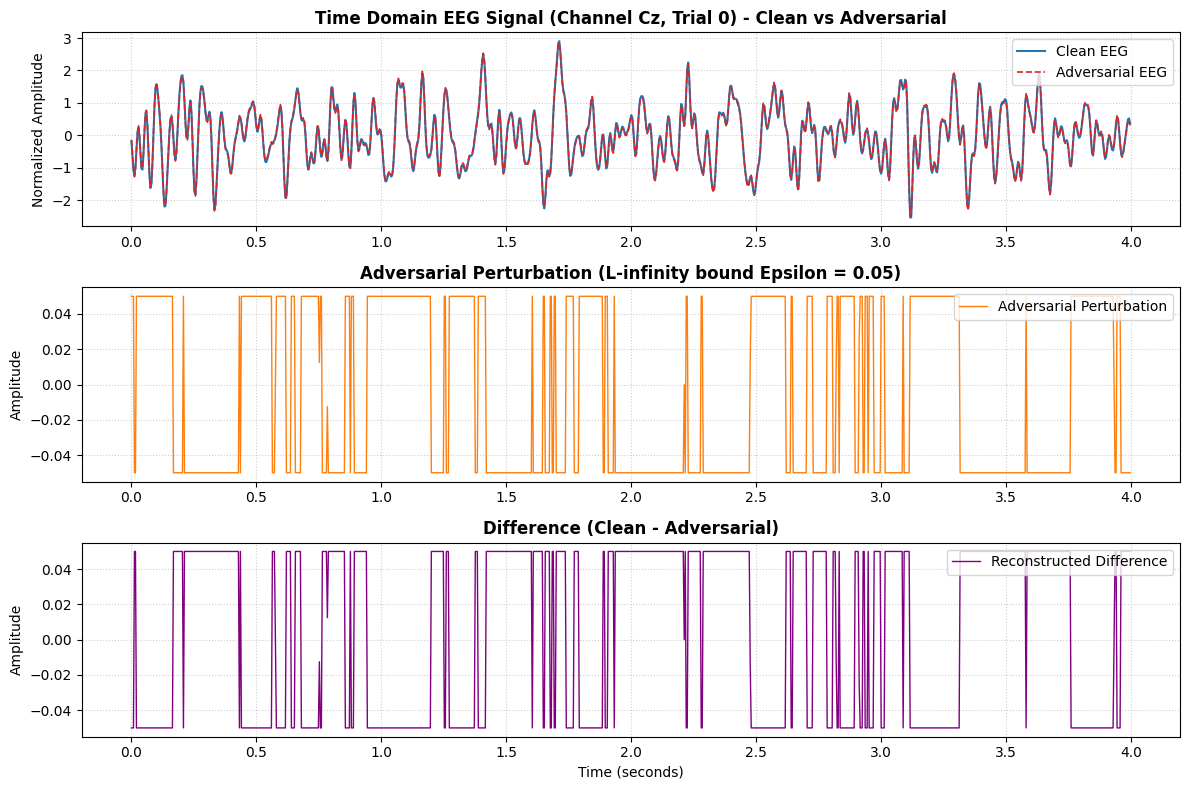

In [4]:
# 4. Time-Domain Signal Plotting (Channel Cz, Trial 0)
trial_idx = 0
cz_idx = 9  # Index 9 in Graz 2a is standard channel Cz
fs = 250.0  # 250 Hz sampling rate
time_axis = np.arange(1000) / fs

plt.figure(figsize=(12, 8))

# Subplot 1: Clean vs Adversarial Overlay
plt.subplot(3, 1, 1)
plt.plot(time_axis, x_clean[trial_idx, 0, cz_idx, :], label='Clean EEG', color='#1f77b4', linewidth=1.5)
plt.plot(time_axis, x_adv[trial_idx, 0, cz_idx, :], label='Adversarial EEG', color='#d62728', linestyle='--', linewidth=1.2)
plt.title('Time Domain EEG Signal (Channel Cz, Trial 0) - Clean vs Adversarial', fontsize=12, fontweight='semibold')
plt.ylabel('Normalized Amplitude', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Adversarial Perturbation
plt.subplot(3, 1, 2)
plt.plot(time_axis, pert[trial_idx, 0, cz_idx, :], label='Adversarial Perturbation', color='#ff7f0e', linewidth=1)
plt.title(f'Adversarial Perturbation (L-infinity bound Epsilon = {epsilon})', fontsize=12, fontweight='semibold')
plt.ylabel('Amplitude', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Clean - Adversarial Difference
plt.subplot(3, 1, 3)
plt.plot(time_axis, x_clean[trial_idx, 0, cz_idx, :] - x_adv[trial_idx, 0, cz_idx, :], label='Reconstructed Difference', color='purple', linewidth=1)
plt.title('Difference (Clean - Adversarial)', fontsize=12, fontweight='semibold')
plt.xlabel('Time (seconds)', fontsize=10)
plt.ylabel('Amplitude', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/time_domain_comparison.png', dpi=300)
plt.show()

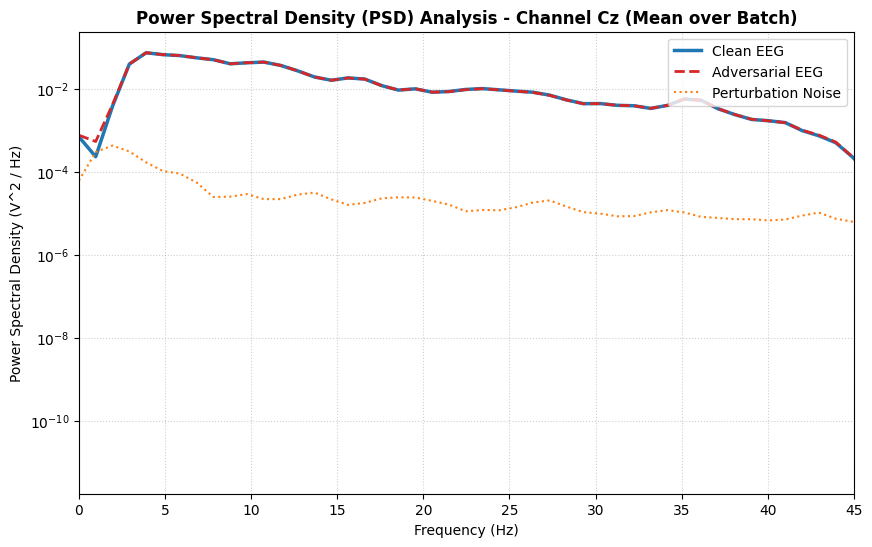

Mu Band (8-13 Hz) clean power: 0.1544, adv power: 0.1545 (Change: +0.07%)
Beta Band (13-30 Hz) clean power: 0.1675, adv power: 0.1670 (Change: -0.29%)


C:\Users\harsh\AppData\Local\Temp\ipykernel_6460\4117367176.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mu_clean_power = np.trapz(mean_psd_clean[mu_indices], freqs[mu_indices])
C:\Users\harsh\AppData\Local\Temp\ipykernel_6460\4117367176.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mu_adv_power = np.trapz(mean_psd_adv[mu_indices], freqs[mu_indices])
C:\Users\harsh\AppData\Local\Temp\ipykernel_6460\4117367176.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  beta_clean_power = np.trapz(mean_psd_clean[beta_indices], freqs[beta_indices])
C:\Users\harsh\AppData\Local\Temp\ipykernel_6460\4117367176.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integ

In [5]:
# 5. Power Spectral Density (PSD) Spectral Analysis
nperseg = 256

# Compute PSD using Welch's method across all trials in the batch for Cz channel
freqs, psd_clean = welch(x_clean[:, 0, cz_idx, :], fs=fs, nperseg=nperseg, axis=1)
_, psd_adv = welch(x_adv[:, 0, cz_idx, :], fs=fs, nperseg=nperseg, axis=1)
_, psd_pert = welch(pert[:, 0, cz_idx, :], fs=fs, nperseg=nperseg, axis=1)

# Mean PSD over the batch
mean_psd_clean = np.mean(psd_clean, axis=0)
mean_psd_adv = np.mean(psd_adv, axis=0)
mean_psd_pert = np.mean(psd_pert, axis=0)

plt.figure(figsize=(10, 6))
plt.semilogy(freqs, mean_psd_clean, label='Clean EEG', color='#1f77b4', linewidth=2.5)
plt.semilogy(freqs, mean_psd_adv, label='Adversarial EEG', color='#d62728', linestyle='--', linewidth=2.0)
plt.semilogy(freqs, mean_psd_pert, label='Perturbation Noise', color='#ff7f0e', linestyle=':', linewidth=1.5)

plt.title('Power Spectral Density (PSD) Analysis - Channel Cz (Mean over Batch)', fontsize=12, fontweight='semibold')
plt.xlabel('Frequency (Hz)', fontsize=10)
plt.ylabel('Power Spectral Density (V^2 / Hz)', fontsize=10)
plt.xlim(0, 45)  # Focus on key EEG bands (Delta to Gamma)
plt.legend(loc='upper right')
plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.savefig('../results/figures/psd_spectral_analysis.png', dpi=300)
plt.show()

# Band-specific power changes: Mu (8-13 Hz) and Beta (13-30 Hz)
mu_indices = np.where((freqs >= 8) & (freqs <= 13))[0]
beta_indices = np.where((freqs >= 13) & (freqs <= 30))[0]

mu_clean_power = np.trapz(mean_psd_clean[mu_indices], freqs[mu_indices])
mu_adv_power = np.trapz(mean_psd_adv[mu_indices], freqs[mu_indices])
beta_clean_power = np.trapz(mean_psd_clean[beta_indices], freqs[beta_indices])
beta_adv_power = np.trapz(mean_psd_adv[beta_indices], freqs[beta_indices])

print(f"Mu Band (8-13 Hz) clean power: {mu_clean_power:.4f}, adv power: {mu_adv_power:.4f} "
      f"(Change: {((mu_adv_power - mu_clean_power) / mu_clean_power) * 100.0:+.2f}%)")
print(f"Beta Band (13-30 Hz) clean power: {beta_clean_power:.4f}, adv power: {beta_adv_power:.4f} "
      f"(Change: {((beta_adv_power - beta_clean_power) / beta_clean_power) * 100.0:+.2f}%)")

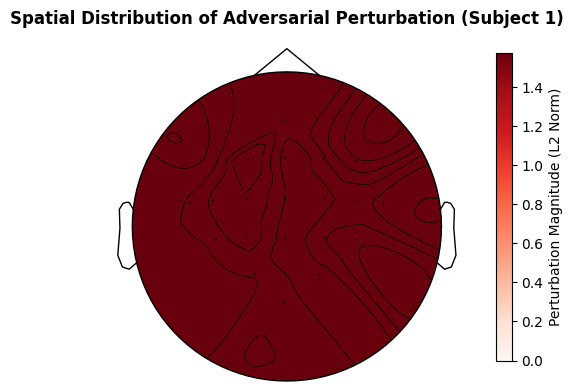

Top 5 Channels Targeted by Adversarial Attack:
1. P2: Magnitude = 1.5772
2. FCz: Magnitude = 1.5771
3. CPz: Magnitude = 1.5771
4. C6: Magnitude = 1.5771
5. C2: Magnitude = 1.5770


In [6]:
# 6. Spatial Topography Mapping using MNE-Python
# 22 Channels mapped from generic GDF labels to standard 10-20 layout
gdf_channels = [
    'EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 
    'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 
    'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16'
]
standard_channels = [
    'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 
    'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 
    'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz'
]

# Compute L2 norm of the perturbation for each channel, averaged across all trials in the batch
# pert shape: (batch, 1, 22, 1000) -> compute L2 norm along time dimension (axis 3) -> mean across batch (axis 0)
channel_pert_magnitudes = np.mean(np.linalg.norm(pert[:, 0, :, :], axis=2), axis=0)

# Create MNE Info object and map 10-20 montage coordinates
info = mne.create_info(ch_names=standard_channels, sfreq=fs, ch_types='eeg')
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage)

fig, ax = plt.subplots(figsize=(6, 5))
im, _ = mne.viz.plot_topomap(channel_pert_magnitudes, info, axes=ax, show=False, cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink=0.8)
cbar.set_label('Perturbation Magnitude (L2 Norm)', fontsize=10)
ax.set_title('Spatial Distribution of Adversarial Perturbation (Subject 1)', fontsize=12, fontweight='semibold')
plt.savefig('../results/figures/spatial_topography_perturbation.png', dpi=300)
plt.show()

# Print top 5 targeted channels
sorted_indices = np.argsort(channel_pert_magnitudes)[::-1]
print("Top 5 Channels Targeted by Adversarial Attack:")
for rank, idx in enumerate(sorted_indices[:5]):
    print(f"{rank+1}. {standard_channels[idx]}: Magnitude = {channel_pert_magnitudes[idx]:.4f}")